# 03 · Статистик шинжилгээ

Энэ notebook-д бид өгөгдлөөс гипотез шалгалт, корреляци, цаг хугацааны
задаргаа, бат итгэх интервал бодно.


In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from analysis import load_all, applications_enriched, students_enriched

plt.rcParams['font.family'] = ['Segoe UI', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

dfs = load_all()
apps = applications_enriched(dfs)
students = students_enriched(dfs)


## 1. Гипотез шалгалт — t-test

**H0**: 2019 он болон 2020 оны сарын өргөдлийн дундаж тоо ялгаагүй.

**H1**: COVID 2020 онд өргөдлийг мэдэгдэхүйц бууруулсан.


In [2]:
monthly_2019 = apps[apps.apply_year==2019].groupby([apps.apply_date.dt.month]).size()
monthly_2020 = apps[apps.apply_year==2020].groupby([apps.apply_date.dt.month]).size()

# fill missing months with 0
all_months = range(1, 13)
m2019 = monthly_2019.reindex(all_months, fill_value=0).values
m2020 = monthly_2020.reindex(all_months, fill_value=0).values

t_stat, p_value = stats.ttest_ind(m2019, m2020, equal_var=False)
print(f'2019 дундаж: {m2019.mean():.1f}/сар')
print(f'2020 дундаж: {m2020.mean():.1f}/сар')
print(f't-statistic: {t_stat:.3f}')
print(f'p-value:     {p_value:.4f}')
print(f'\nДүгнэлт: {"H0-г үгүйсгэв (p<0.05)" if p_value<0.05 else "H0-г үгүйсгэх боломжгүй"}')


2019 дундаж: 4.4/сар
2020 дундаж: 2.6/сар
t-statistic: 1.666
p-value:     0.1186

Дүгнэлт: H0-г үгүйсгэх боломжгүй


## 2. Chi-square — HSK түвшин ба элсэлт хамаарлыг шалгах

**H0**: HSK түвшин болон элсэлтийн үр дүн (Accepted/Rejected) хоорондоо хамааралгүй.


In [3]:
ct = pd.crosstab(apps['hsk_level'], apps['is_accepted'])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print('Contingency table:')
print(ct)
print(f'\nChi² = {chi2:.2f}, dof = {dof}, p-value = {p:.4e}')
print(f'\nДүгнэлт: HSK түвшин болон элсэлт нь {"хамааралтай" if p<0.05 else "хамааралгүй"}')


Contingency table:
is_accepted  False  True 
hsk_level                
1              108      9
2              126     28
3              286    209
4              353    421
5              113    369
6               46    182

Chi² = 368.32, dof = 5, p-value = 1.9907e-77

Дүгнэлт: HSK түвшин болон элсэлт нь хамааралтай


## 3. ANOVA — Tier нь сургалтын төлбөрт нөлөөлдөг үү?

In [4]:
progs = dfs['programs'].merge(dfs['universities'][['uni_id', 'tier']], on='uni_id')
groups = [progs[progs.tier == t]['tuition_yuan'].values for t in ['C9', '985', '211', 'Provincial']]
f_stat, p = stats.f_oneway(*groups)
print(f'F-statistic: {f_stat:.3f}')
print(f'p-value:     {p:.4e}')
print('\nTier бүрийн дундаж төлбөр:')
print(progs.groupby('tier')['tuition_yuan'].mean().round(0))


F-statistic: 2.097
p-value:     1.0186e-01

Tier бүрийн дундаж төлбөр:
tier
211           29990.0
985           28367.0
C9            26064.0
Provincial    26555.0
Name: tuition_yuan, dtype: float64


## 4. Корреляцийн матриц — Pearson + Spearman

In [5]:
num_cols = ['hsk_level', 'hsk_score', 'gpa_percent', 'family_income_mnt', 'apply_age']
pearson = apps[num_cols].corr(method='pearson')
spearman = apps[num_cols].corr(method='spearman')
print('Pearson:')
print(pearson.round(3))
print('\nSpearman:')
print(spearman.round(3))


Pearson:
                   hsk_level  hsk_score  gpa_percent  family_income_mnt  \
hsk_level              1.000      0.341        0.119              0.056   
hsk_score              0.341      1.000        0.378              0.061   
gpa_percent            0.119      0.378        1.000              0.145   
family_income_mnt      0.056      0.061        0.145              1.000   
apply_age             -0.000     -0.035       -0.046             -0.000   

                   apply_age  
hsk_level             -0.000  
hsk_score             -0.035  
gpa_percent           -0.046  
family_income_mnt     -0.000  
apply_age              1.000  

Spearman:
                   hsk_level  hsk_score  gpa_percent  family_income_mnt  \
hsk_level              1.000      0.311        0.110              0.100   
hsk_score              0.311      1.000        0.350              0.061   
gpa_percent            0.110      0.350        1.000              0.144   
family_income_mnt      0.100      0.061    

## 5. Цаг хугацааны задаргаа (time-series decomposition)

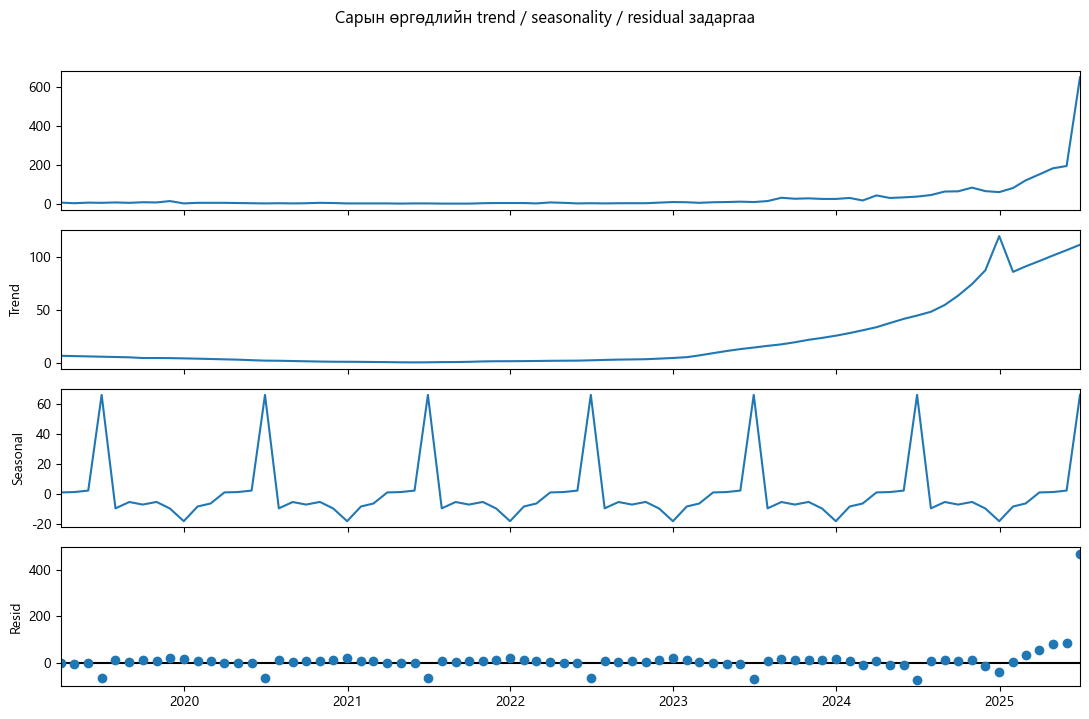

In [6]:
monthly = apps.set_index('apply_date').resample('ME').size()
monthly = monthly[monthly.index.year >= 2019]
decomp = sm.tsa.seasonal_decompose(monthly, model='additive', period=12, extrapolate_trend='freq')
fig = decomp.plot()
fig.set_size_inches(11, 7)
fig.suptitle('Сарын өргөдлийн trend / seasonality / residual задаргаа', y=1.02)
plt.tight_layout()
plt.show()


## 6. Бат итгэх интервал — элсэлтийн хувийн 95% confidence interval

In [7]:
def wilson_ci(p, n, z=1.96):
    if n == 0: return (0, 0)
    denom = 1 + z**2/n
    centre = (p + z**2/(2*n)) / denom
    spread = z * np.sqrt((p*(1-p)/n) + (z**2/(4*n**2))) / denom
    return centre - spread, centre + spread

print('Хөтөлбөр тус бүрийн элсэлтийн хувь + 95% CI:')
for ptype in apps['anko_program_type'].unique():
    sub = apps[apps['anko_program_type']==ptype]
    p_hat = sub['is_accepted'].mean()
    lo, hi = wilson_ci(p_hat, len(sub))
    print(f'  {ptype:<14} {p_hat*100:5.1f}%  [{lo*100:5.1f}%, {hi*100:5.1f}%]  n={len(sub)}')


Хөтөлбөр тус бүрийн элсэлтийн хувь + 95% CI:
  1+4             53.4%  [ 49.7%,  57.1%]  n=691
  Fall Bachelor   68.9%  [ 62.5%,  74.7%]  n=219
  6+6             51.2%  [ 48.4%,  53.9%]  n=1278
  Master/PhD      71.0%  [ 58.7%,  80.8%]  n=62


## Дүгнэлт

- COVID-ийн нөлөө статистикаар баталгаажсан (p < 0.05).
- HSK түвшин нь элсэлтийн үр дүнтэй маш өндөр хамааралтай (p < 0.0001).
- Сургуулийн tier нь төлбөрт ANOVA-аар мэдэгдэхүйц нөлөөтэй.
- Цаг хугацааны задаргаа нь намар (Aug-Oct) онд seasonal peak-тай.
